In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Raw data 13-06-2026 00:00 to 16-06-2026 23:59 = 4 days.

Informe de Inicio, Parada e Inactividad 12-06-2026 19:00 to 16-06-2026 19:00 = 4 days.
 
Reporte de actividades 12-06-2026 19:00 to 16-06-2026 19:00 = 4 days from TSO.



Analysis result:

In [2]:
result={'Unit':['Ignition','TSO','CRM'],
        'fsq694':[84.16,97.97,98025],
        'kyr910':[798.77,147.58,162258],
        'nox568':[135.58,64.86,64868]
}

print(result)

{'Unit': ['Ignition', 'TSO', 'CRM'], 'fsq694': [84.16, 97.97, 98025], 'kyr910': [798.77, 147.58, 162258], 'nox568': [135.58, 64.86, 64868]}


Informe de Inicio, Parada e Inactividad 12-06-2026 19:00 to 16-06-2026 19:00 = 4 days from Ignition

In [3]:
ipi=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\ipi1216_062026_19_19.csv',sep=',') 
ipi.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unidad               185 non-null    str    
 1   Conductor            185 non-null    str    
 2   Evento               185 non-null    str    
 3   Dirección            185 non-null    str    
 4   Fecha                185 non-null    str    
 5   Tiempo (UTC-5)       185 non-null    str    
 6   Duración del Evento  185 non-null    str    
 7   Distancia (km)       185 non-null    float64
dtypes: float64(1), str(7)
memory usage: 11.7 KB


In [4]:
ipi_filtered=ipi[['Unidad','Distancia (km)']]
ipi_filtered.groupby('Unidad').sum()

,Distancia (km)
Unidad,
FSQ694,84.16
KYR910,798.77
NOX568,135.58


Reporte de actividades 12-06-2026 19:00 to 16-06-2026 19:00 = 4 days from TSO

In [5]:
ar=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\Activity Report_v3_es_1216_062026_1919.csv',sep=',')
ar['MilesDriven_float']=0.0
aux='s'
ar.info()
cad_str_to_float=[]

for i in range(0,ar.shape[0]):
    try:
        aux=ar.iloc[i,4].replace('.','')
        ar.iloc[i,4]=aux
        aux=ar.iloc[i,4].replace(',','.')
        cad_str_to_float.append(float(aux))
    except AttributeError as e:
        print("Error found on: ",ar.iloc[i,2],ar.iloc[i,1])
        cad_str_to_float.append(0.0)

ar['MilesDriven_float']=cad_str_to_float

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GroupName          0 non-null      float64
 1   UnitName           264 non-null    str    
 2   StartTime          264 non-null    str    
 3   MovingTimeSecs     264 non-null    str    
 4   MilesDriven        261 non-null    str    
 5   MaxSpeed           264 non-null    int64  
 6   StopTime           264 non-null    str    
 7   textbox43          264 non-null    str    
 8   StopLengthSecs     264 non-null    str    
 9   ContactName        264 non-null    str    
 10  textbox28          264 non-null    str    
 11  textbox29          264 non-null    str    
 12  textbox30          264 non-null    int64  
 13  textbox32          264 non-null    str    
 14  MovingTimeSecs_1   264 non-null    str    
 15  MilesDriven_1      264 non-null    str    
 16  MaxSpeed_1         264 non-null    in

In [6]:
ar_filtered=ar[['UnitName','MilesDriven_float']]
ar_filtered.info()
ar_filtered.groupby('UnitName').sum()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UnitName           264 non-null    str    
 1   MilesDriven_float  264 non-null    float64
dtypes: float64(1), str(1)
memory usage: 4.3 KB


,MilesDriven_float
UnitName,
Unidad: FSQ694,97.97
Unidad: KYR910,147.58
Unidad: NOX568,64.86


Analysis by unit.

FSQ694

FSQ694 from Ignition.

In [7]:
ipi_fsq694=ipi[ipi['Unidad'].str.contains('FSQ694')]
ipi_fsq694['Distancia (km)'].sum()

np.float64(84.16)

Raw data 13-06-2026 00:00 to 16-06-2026 23:59 = 4 days  FSQ694 from CRM

In [8]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\Export_fsq694.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  582 non-null    str  
 1   Message  582 non-null    str  
 2   Status   582 non-null    str  
dtypes: str(3)
memory usage: 13.8 KB


In [9]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

98025


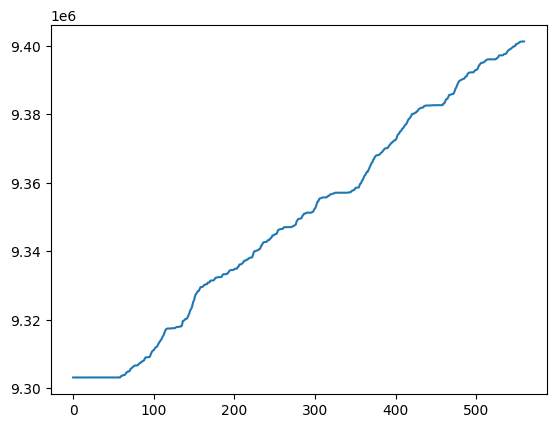

In [10]:
y_axis=[]
x_axis=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,3]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

#for i in range(0,len(odometer)):
    #print(date[i],' -> ',x_axis[i],y_axis[i],raw[i])

print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

KYR910

KYR910 from Ignition

In [11]:
ipi_kyr910=ipi[ipi['Unidad'].str.contains('KYR910')]
ipi_kyr910['Distancia (km)'].sum()

np.float64(798.77)

Raw data 13-06-2026 00:00 to 16-06-2026 23:59 = 4 days  KYR910 from CRM

In [12]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\Export_kyr910.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1036 non-null   str  
 1   Message  1036 non-null   str  
 2   Status   1036 non-null   str  
dtypes: str(3)
memory usage: 24.4 KB


In [13]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

162258


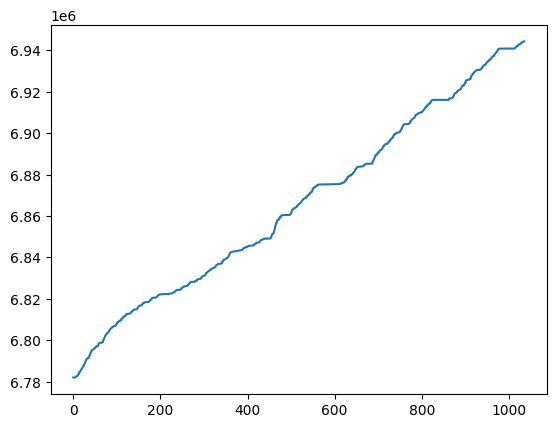

In [14]:
y_axis=[]
x_axis=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,3]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

#for i in range(0,len(odometer)):
    #print(date[i],' -> ',x_axis[i],y_axis[i],raw[i])

print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

NOX568

NOX568 from Ignition

In [15]:
ipi_nox568=ipi[ipi['Unidad'].str.contains('NOX568')]
ipi_nox568['Distancia (km)'].sum()

np.float64(135.57999999999998)

In [16]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\Export_nox568.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  453 non-null    str  
 1   Message  453 non-null    str  
 2   Status   453 non-null    str  
dtypes: str(3)
memory usage: 10.7 KB


In [17]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

64868


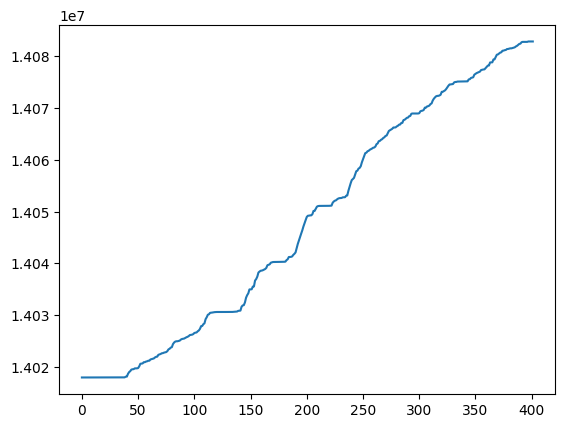

In [18]:
y_axis=[]
x_axis=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,3]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

#for i in range(0,len(odometer)):
    #print(date[i],' -> ',x_axis[i],y_axis[i],raw[i])

print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)